# Workshop Notebook 1 — Multi-Omics Representation Learning with a VAE

In this workshop, we combine three molecular measurements from the same breast-cancer patients into a compact patient representation. Rather than predicting a known label, a Variational Autoencoder (VAE) learns patterns directly from the multi-omics data.

## 1. Workshop setup and frozen data

Before starting:

1. Clone or download this GitHub repository.
2. Confirm that these four files are present in `data/processed/`:
   - `TCGA_BRCA_RNA_selected.tsv`
   - `TCGA_BRCA_miRNA_selected.tsv`
   - `TCGA_BRCA_methylation_selected.tsv`
   - `TCGA_BRCA_cohort_metadata.tsv`
3. No raw TCGA download or preprocessing is required for this notebook.

The supplied dataset is a frozen cohort of **617 patients** with **2,300 selected molecular features** across RNA-seq, miRNA, and DNA methylation. Keeping the cohort and features fixed lets us focus on the representation-learning workflow.

**Next,** load the four frozen files and inspect their dimensions. **Look for** one matrix per molecular assay, plus patient metadata, all with 617 rows.

## 2. What are RNA-seq, miRNA, and DNA methylation?

- **RNA-seq** measures gene-expression levels: which genes are more or less active.
- **miRNA** measures small regulatory RNAs that can influence gene expression.
- **DNA methylation** measures a chemical mark on DNA that is associated with gene regulation.

These assays describe related but different aspects of a tumour. Their values and feature sets differ, so integration needs careful scaling and a shared representation.

## 3. Why multi-omics integration?

Using the three assays together can reveal patient-to-patient patterns that are not visible in a single modality. Here, integration means learning one common representation from the concatenated, scaled measurements.

## 4. Why dimensionality reduction / representation learning?

Working directly with 2,300 features makes visualisation and patient grouping difficult. A VAE compresses each patient into 10 latent coordinates while retaining patterns useful for reconstructing the input. This is an unsupervised task: no subtype labels are supplied to the model.


In [21]:
from pathlib import Path
import pandas as pd

# Project root = folder containing this notebook's parent directory
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Load frozen TCGA-BRCA multi-omics data
rna = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",
    sep="\t",
    index_col=0
)

mirna = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv",
    sep="\t",
    index_col=0
)

methylation = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv",
    sep="\t",
    index_col=0
)

cohort_meta = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
    sep="\t",
    index_col=0
)

print("Frozen TCGA-BRCA dataset loaded")
print(f"RNA:          {rna.shape}")
print(f"miRNA:        {mirna.shape}")
print(f"Methylation:  {methylation.shape}")
print(f"Metadata:     {cohort_meta.shape}")

Frozen TCGA-BRCA dataset loaded
RNA:          (617, 1000)
miRNA:        (617, 300)
Methylation:  (617, 1000)
Metadata:     (617, 3)


## Prepare the modelling environment

**Next,** import the tools, fix the random seed, and reload the frozen matrices for the modelling workflow. The code also checks that every assay uses the same ordered patient cohort. **Look for** the PyTorch version, the seed, and matching 617-sample dimensions.


In [22]:
import random, time, json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Global seeds ───────────────────────────────────────────────────────────────
VAE_SEED = 42
random.seed(VAE_SEED)
np.random.seed(VAE_SEED)
torch.manual_seed(VAE_SEED)
torch.backends.cudnn.deterministic = True

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : CPU")
print(f"Random seed     : {VAE_SEED}")

# ── Load frozen processed matrices from disk ───────────────────────────────────
rna_df   = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",   sep="\t", index_col=0)
mirna_df = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv", sep="\t", index_col=0)
meth_df  = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv", sep="\t", index_col=0)
cohort   = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv", sep="\t", index_col="sample_id")
frozen_ids = cohort.index.tolist()

# ── Verify sample IDs match frozen cohort ─────────────────────────────────────
assert list(rna_df.index)   == frozen_ids, "RNA sample ID mismatch"
assert list(mirna_df.index) == frozen_ids, "miRNA sample ID mismatch"
assert list(meth_df.index)  == frozen_ids, "Methylation sample ID mismatch"
print(f"\n✅ All matrices loaded and sample IDs match frozen cohort ({len(frozen_ids)} samples)")
print(f"  RNA   : {rna_df.shape}")
print(f"  miRNA : {mirna_df.shape}")
print(f"  Meth  : {meth_df.shape}")

PyTorch version : 2.13.0+cpu
Device          : CPU
Random seed     : 42

✅ All matrices loaded and sample IDs match frozen cohort (617 samples)
  RNA   : (617, 1000)
  miRNA : (617, 300)
  Meth  : (617, 1000)


## 5. Train/validation split and avoiding data leakage

**Next,** split patients into training (80%) and validation (20%) sets, scale each assay using the training patients only, then combine the three scaled matrices. Fitting the scalers only on training data avoids leaking information from validation patients into model preparation. **Look for** the split sizes, a 617 × 2,300 combined matrix, and a near-zero training-set mean after scaling.


In [7]:
# ── Train / validation split ───────────────────────────────────────────────────
VAL_FRAC   = 0.20
BATCH_SIZE = 64

sample_array = np.array(frozen_ids)
idx_all      = np.arange(len(sample_array))

idx_train, idx_val = train_test_split(
    idx_all, test_size=VAL_FRAC, random_state=VAE_SEED, shuffle=True
)

train_ids = sample_array[idx_train].tolist()
val_ids   = sample_array[idx_val].tolist()

print(f"Train samples : {len(train_ids)}  ({100*(1-VAL_FRAC):.0f}%)")
print(f"Val   samples : {len(val_ids)}   ({100*VAL_FRAC:.0f}%)")

# ── Per-modality StandardScaler — fit on TRAINING split only ──────────────────
def fit_scale(df, train_ids):
    scaler = StandardScaler()
    scaler.fit(df.loc[train_ids].values)
    return scaler, scaler.transform(df.values).astype(np.float32)

scaler_rna,   rna_scaled   = fit_scale(rna_df,   train_ids)
scaler_mirna, mirna_scaled = fit_scale(mirna_df, train_ids)
scaler_meth,  meth_scaled  = fit_scale(meth_df,  train_ids)

# ── Concatenate ────────────────────────────────────────────────────────────────
X_all = np.concatenate([rna_scaled, mirna_scaled, meth_scaled], axis=1)   # (617, 2300)
INPUT_DIM = X_all.shape[1]

print(f"\nConcatenated multi-omics matrix : {X_all.shape}")
print(f"  RNA     : cols 0–{rna_scaled.shape[1]-1}")
print(f"  miRNA   : cols {rna_scaled.shape[1]}–{rna_scaled.shape[1]+mirna_scaled.shape[1]-1}")
print(f"  Meth    : cols {rna_scaled.shape[1]+mirna_scaled.shape[1]}–{INPUT_DIM-1}")

# Verify scalers were fit on training data only
rna_train_mean = rna_scaled[idx_train].mean(axis=0).mean()
print(f"\nPost-scaling train mean (RNA, should ≈ 0): {rna_train_mean:.4f}")

# ── Build PyTorch tensors and DataLoaders ─────────────────────────────────────
X_tensor = torch.tensor(X_all, dtype=torch.float32)

X_train_t = X_tensor[idx_train]
X_val_t   = X_tensor[idx_val]

torch.manual_seed(VAE_SEED)
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=False)
val_loader   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH_SIZE,
                          shuffle=False, drop_last=False)

print(f"\nTrain batches per epoch : {len(train_loader)}")
print(f"Val   batches per epoch : {len(val_loader)}")

Train samples : 493  (80%)
Val   samples : 124   (20%)

Concatenated multi-omics matrix : (617, 2300)
  RNA     : cols 0–999
  miRNA   : cols 1000–1299
  Meth    : cols 1300–2299

Post-scaling train mean (RNA, should ≈ 0): -0.0000

Train batches per epoch : 8
Val   batches per epoch : 2


## 6. VAE architecture

**Next,** define a VAE that encodes 2,300 molecular features into 10 latent dimensions and decodes them back to the original feature space. The VAE learns a mean and variance for each latent coordinate, and its loss balances reconstruction with a regularising KL-divergence term. **Look for** the printed model architecture and trainable-parameter count.


In [8]:
LATENT_DIM = 10
BETA       = 1.0    # baseline beta; not tuned in this first run


class Encoder(nn.Module):
    """2300 → 256 → 64 → (mu, logvar) each of dimension LATENT_DIM."""

    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """LATENT_DIM → 64 → 256 → 2300 (linear output for standardised continuous data)."""

    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),   nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 256),          nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, output_dim),  # no activation — output is real-valued (standardised)
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)

    def reparameterize(self, mu, logvar):
        """z = mu + eps * sigma, eps ~ N(0, I). Gradient flows through mu and sigma."""
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu   # deterministic at inference

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar


def vae_loss(x, x_hat, mu, logvar, beta):
    """
    total_loss = recon_loss + beta * kl_loss

    recon_loss: MSE averaged per element (not per sample) so it is on the same
                scale regardless of batch size or input dimension.

    kl_loss: KL divergence averaged per element of the latent space
             (sum over latent dims, mean over batch, divided by input_dim)
             so that its scale is comparable to recon_loss.

    This normalisation prevents kl_loss from being trivially small compared
    to recon_loss and makes beta=1.0 a sensible starting point.
    """
    recon = F.mse_loss(x_hat, x, reduction="mean")          # scalar, O(1)
    # KL(N(mu,sigma) || N(0,1)) = -0.5 * (1 + logvar - mu^2 - exp(logvar))
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (B, latent)
    kl = kl_per_dim.sum(dim=1).mean() / x.shape[1]              # normalised by input_dim
    return recon + beta * kl, recon, kl


# ── Instantiate ────────────────────────────────────────────────────────────────
torch.manual_seed(VAE_SEED)
vae = VAE(INPUT_DIM, LATENT_DIM)
n_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print("VAE architecture:")
print(vae)
print(f"\nTotal trainable parameters: {n_params:,}")
print(f"Latent dimension          : {LATENT_DIM}")
print(f"Input dimension           : {INPUT_DIM}")
print(f"Beta (KL weight)          : {BETA}")

VAE architecture:
VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=2300, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=64, out_features=10, bias=True)
    (fc_logvar): Linear(in_features=64, out_features=10, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=10, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6):

## 7. VAE training

**Next,** train the VAE on the training split and monitor loss on held-out validation patients. Early stopping keeps the best validation checkpoint rather than assuming that the final epoch is best. **Look for** periodic training/validation losses, the stopping epoch, and the best validation loss.


In [9]:
LR         = 1e-3
MAX_EPOCHS = 200
PATIENCE   = 20    # early stopping patience

CHECKPOINT_PATH = PROCESSED_DIR / "TCGA_BRCA_VAE_best.pt"

optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

history = {k: [] for k in
           ["train_total","train_recon","train_kl",
            "val_total",  "val_recon",  "val_kl"]}

best_val_loss  = float("inf")
best_epoch     = 0
patience_count = 0
t_start        = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Training ──────────────────────────────────────────────────────────────
    vae.train()
    tr_tot = tr_rec = tr_kl = 0.0
    for (xb,) in train_loader:
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(xb)
        loss, recon, kl   = vae_loss(xb, x_hat, mu, logvar, BETA)
        loss.backward()
        optimizer.step()
        tr_tot += loss.item();  tr_rec += recon.item();  tr_kl += kl.item()

    n_tr = len(train_loader)
    history["train_total"].append(tr_tot / n_tr)
    history["train_recon"].append(tr_rec / n_tr)
    history["train_kl"].append(tr_kl / n_tr)

    # ── Validation ────────────────────────────────────────────────────────────
    vae.eval()
    va_tot = va_rec = va_kl = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            x_hat, mu, logvar = vae(xb)
            loss, recon, kl   = vae_loss(xb, x_hat, mu, logvar, BETA)
            va_tot += loss.item();  va_rec += recon.item();  va_kl += kl.item()

    n_va = len(val_loader)
    val_total = va_tot / n_va
    history["val_total"].append(val_total)
    history["val_recon"].append(va_rec / n_va)
    history["val_kl"].append(va_kl / n_va)

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_total < best_val_loss:
        best_val_loss  = val_total
        best_epoch     = epoch
        patience_count = 0
        torch.save({"epoch": epoch, "model_state": vae.state_dict(),
                    "val_loss": best_val_loss}, CHECKPOINT_PATH)
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"train total={history['train_total'][-1]:.5f} "
              f"recon={history['train_recon'][-1]:.5f} "
              f"kl={history['train_kl'][-1]:.5f} | "
              f"val total={history['val_total'][-1]:.5f} "
              f"recon={history['val_recon'][-1]:.5f} "
              f"kl={history['val_kl'][-1]:.5f}")

elapsed = time.time() - t_start
print(f"\nTraining finished: {len(history['train_total'])} epochs in {elapsed:.1f}s")
print(f"Best epoch: {best_epoch}  |  best val loss: {best_val_loss:.5f}")

Epoch   1 | train total=1.08313 recon=1.08220 kl=0.00094 | val total=0.91192 recon=0.90953 kl=0.00240
Epoch  20 | train total=0.62779 recon=0.61896 kl=0.00883 | val total=0.63263 recon=0.62488 kl=0.00775
Epoch  40 | train total=0.55791 recon=0.54701 kl=0.01090 | val total=0.61334 recon=0.60348 kl=0.00986
Epoch  60 | train total=0.50319 recon=0.49113 kl=0.01206 | val total=0.60461 recon=0.59362 kl=0.01100
Epoch  80 | train total=0.46559 recon=0.45280 kl=0.01279 | val total=0.61017 recon=0.59846 kl=0.01171
Early stopping at epoch 89 (no improvement for 20 epochs)

Training finished: 89 epochs in 18.0s
Best epoch: 69  |  best val loss: 0.60409


## 8. Training/validation loss

**Next,** plot total, reconstruction, and KL losses over training. Comparing training and validation curves helps assess whether learning is stable; the KL diagnostic checks whether the latent regularisation is contributing. **Look for** broadly stable validation behaviour and the printed KL/reconstruction summary.


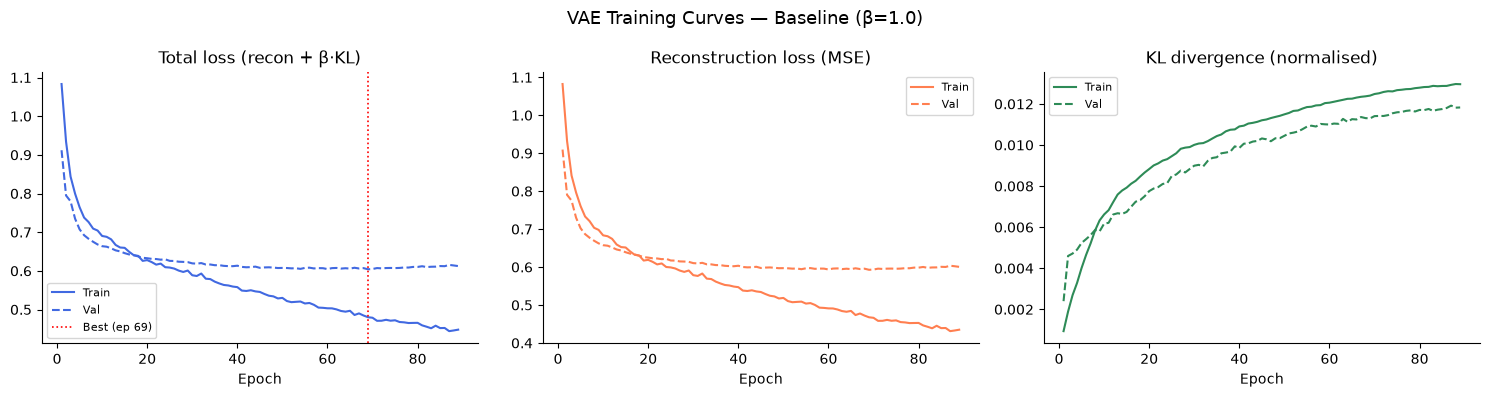

Final train recon loss : 0.43496
Final train KL loss    : 0.01296
KL / recon ratio       : 0.0298
✅ KL loss is non-trivial. Latent space appears to be utilised.


In [10]:
actual_epochs = len(history["train_total"])
epochs_range  = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(epochs_range, history["train_total"], label="Train", color="royalblue")
axes[0].plot(epochs_range, history["val_total"],   label="Val",   color="royalblue", linestyle="--")
axes[0].axvline(best_epoch, color="red", linestyle=":", linewidth=1.2, label=f"Best (ep {best_epoch})")
axes[0].set_title("Total loss (recon + β·KL)"); axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8); axes[0].spines[["top","right"]].set_visible(False)

# Reconstruction loss
axes[1].plot(epochs_range, history["train_recon"], label="Train", color="coral")
axes[1].plot(epochs_range, history["val_recon"],   label="Val",   color="coral", linestyle="--")
axes[1].set_title("Reconstruction loss (MSE)"); axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8); axes[1].spines[["top","right"]].set_visible(False)

# KL loss
axes[2].plot(epochs_range, history["train_kl"], label="Train", color="seagreen")
axes[2].plot(epochs_range, history["val_kl"],   label="Val",   color="seagreen", linestyle="--")
axes[2].set_title("KL divergence (normalised)"); axes[2].set_xlabel("Epoch")
axes[2].legend(fontsize=8); axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("VAE Training Curves — Baseline (β=1.0)", fontsize=13)
plt.tight_layout()
plt.show()

# ── KL collapse diagnosis ──────────────────────────────────────────────────────
final_kl   = history["train_kl"][-1]
final_recon = history["train_recon"][-1]
kl_ratio   = final_kl / (final_recon + 1e-9)

print(f"Final train recon loss : {final_recon:.5f}")
print(f"Final train KL loss    : {final_kl:.5f}")
print(f"KL / recon ratio       : {kl_ratio:.4f}")

if final_kl < 1e-4:
    print("⚠️  KL COLLAPSE detected: KL term is near-zero.")
    print("   The encoder is outputting near-posterior ≈ prior for all samples.")
    print("   This means the latent space carries no information beyond the prior.")
    print("   Do NOT automatically fix this — report and await instruction.")
elif kl_ratio < 0.01:
    print("⚠️  KL is very small relative to reconstruction (ratio < 0.01).")
    print("   Mild collapse risk. Latent space may be underutilised.")
else:
    print("✅ KL loss is non-trivial. Latent space appears to be utilised.")

## 9. Extracting the latent representation

**Next,** reload the best VAE checkpoint and encode all 617 patients into their 10-dimensional latent representation. The mean latent coordinates are saved for the visualisation and clustering steps. **Look for** a 617 × 10 latent matrix and confirmation that it was saved under `data/processed/`.


In [11]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT_PATH, weights_only=True)
vae.load_state_dict(ckpt["model_state"])
vae.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.5f})")

# ── Extract latent representation for ALL 617 samples ─────────────────────────
with torch.no_grad():
    mu_all, logvar_all = vae.encoder(X_tensor)

mu_np = mu_all.numpy()         # (617, 10)

latent_cols = [f"z{i+1}" for i in range(LATENT_DIM)]
latent_df   = pd.DataFrame(mu_np, index=frozen_ids, columns=latent_cols)
latent_df.index.name = "sample_id"

print(f"\nLatent representation shape : {latent_df.shape}")
print(f"  Columns: {latent_cols}")
print(f"\nLatent coordinate statistics:")
print(latent_df.describe().round(4).to_string())

# ── Save latent matrix ─────────────────────────────────────────────────────────
LATENT_OUT = PROCESSED_DIR / "TCGA_BRCA_VAE_latent.tsv"
latent_df.to_csv(LATENT_OUT, sep="\t", float_format="%.6f")
print(f"\n✅ Saved latent matrix: {LATENT_OUT.name}  "
      f"({LATENT_OUT.stat().st_size/1e3:.1f} KB)")

# ── Save VAE metadata JSON ─────────────────────────────────────────────────────
vae_metadata = {
    "created"         : str(date.today()),
    "model_type"      : "Variational Autoencoder (VAE)",
    "input_dim"       : INPUT_DIM,
    "architecture"    : {
        "encoder" : "Linear(2300→256, BN+ReLU) → Linear(256→64, BN+ReLU) → mu(64→10), logvar(64→10)",
        "decoder" : "Linear(10→64, BN+ReLU) → Linear(64→256, BN+ReLU) → Linear(256→2300)",
        "output_activation" : "none (linear — standardised continuous data)",
    },
    "latent_dim"      : LATENT_DIM,
    "beta"            : BETA,
    "loss_normalisation": "recon=MSE(mean), kl=sum_over_latent/mean_over_batch/input_dim",
    "optimizer"       : "Adam",
    "learning_rate"   : LR,
    "batch_size"      : BATCH_SIZE,
    "max_epochs"      : MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "actual_epochs"   : actual_epochs,
    "best_epoch"      : best_epoch,
    "random_seed"     : VAE_SEED,
    "train_val_split" : f"{int(100*(1-VAL_FRAC))}/{int(100*VAL_FRAC)}",
    "n_train"         : len(train_ids),
    "n_val"           : len(val_ids),
    "final_train_total" : round(history["train_total"][-1], 6),
    "final_train_recon" : round(history["train_recon"][-1], 6),
    "final_train_kl"    : round(history["train_kl"][-1],    6),
    "best_val_total"    : round(best_val_loss, 6),
    "best_val_recon"    : round(history["val_recon"][best_epoch-1], 6),
    "best_val_kl"       : round(history["val_kl"][best_epoch-1],    6),
    "kl_collapse"       : final_kl < 1e-4,
    "latent_output_file": "TCGA_BRCA_VAE_latent.tsv",
    "checkpoint_file"   : "TCGA_BRCA_VAE_best.pt",
    "notes"             : (
        "Baseline VAE. PAM50 not used at any stage. "
        "Latent representation (mu) extracted for all 617 samples. "
        "No UMAP or clustering performed yet."
    ),
}

VAE_META_PATH = PROCESSED_DIR / "TCGA_BRCA_VAE_metadata.json"
with open(VAE_META_PATH, "w") as fh:
    json.dump(vae_metadata, fh, indent=2)
print(f"✅ Saved VAE metadata   : {VAE_META_PATH.name}")

print()
print("=" * 65)
print("  BASELINE VAE COMPLETE")
print("=" * 65)
print(f"  Epochs trained         : {actual_epochs}")
print(f"  Best epoch (val)       : {best_epoch}")
print(f"  Final train total      : {vae_metadata['final_train_total']:.5f}")
print(f"  Final train recon      : {vae_metadata['final_train_recon']:.5f}")
print(f"  Final train KL         : {vae_metadata['final_train_kl']:.5f}")
print(f"  Best val total         : {vae_metadata['best_val_total']:.5f}")
print(f"  KL collapse            : {vae_metadata['kl_collapse']}")
print(f"  Latent matrix shape    : {latent_df.shape}")
print("=" * 65)
print("⛔ STOP — Do not perform UMAP, clustering, or PAM50 comparison yet.")

Loaded best model from epoch 69 (val_loss=0.60409)

Latent representation shape : (617, 10)
  Columns: ['z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10']

Latent coordinate statistics:
             z1        z2        z3        z4        z5        z6        z7        z8        z9       z10
count  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000
mean    -0.0289   -0.0470   -0.0067   -0.0483   -0.0274    0.0218   -0.0411   -0.0045    0.0707    0.0304
std      1.0262    1.0862    1.1945    1.3213    1.3071    1.4360    1.3549    1.2177    1.2772    1.2272
min     -3.6048   -2.5050   -3.8045   -3.6441   -3.2386   -4.0335   -3.1482   -2.9033   -4.4867   -3.7078
25%     -0.6727   -0.9441   -0.7726   -1.0770   -0.9345   -0.9843   -0.9739   -0.9354   -0.7664   -0.8528
50%     -0.0285   -0.0634    0.0973   -0.0102   -0.1666    0.0759   -0.1295   -0.1744    0.1745   -0.0265
75%      0.6621    0.6949    0.8325    0.9134    0.8043    0.9

## 10. Visualizing the latent space with UMAP

**Next,** load the 10-dimensional VAE representation and use UMAP to make a two-dimensional display. UMAP is only a visual summary; the original 10-dimensional latent coordinates remain the basis for clustering. **Look for** confirmation of the latent matrix and the 2D UMAP shape.


In [12]:
import umap as umap_lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import seaborn as sns

# ── Load latent matrix from disk ───────────────────────────────────────────────
latent_df = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_VAE_latent.tsv",
                        sep="\t", index_col="sample_id")
print(f"Latent matrix: {latent_df.shape}")

# ── Attach PAM50 labels (post-hoc only) ────────────────────────────────────────
cohort_meta = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
                          sep="\t", index_col="sample_id")

# Use 'Unknown' for missing labels; preserve all 617 samples
pam50_labels = cohort_meta["PAM50_subtype"].reindex(latent_df.index).fillna("Unknown")
print(f"PAM50 distribution (all 617, 'Unknown' for unlabelled):")
print(pam50_labels.value_counts().to_string())

# ── UMAP on latent representation (UMAP sees NO labels) ───────────────────────
UMAP_SEED = 42
reducer = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=UMAP_SEED)
Z_2d = reducer.fit_transform(latent_df.values)   # fit on all 617 samples, no labels
print(f"\nUMAP embedding shape: {Z_2d.shape}")

Latent matrix: (617, 10)
PAM50 distribution (all 617, 'Unknown' for unlabelled):
PAM50_subtype
Unknown    238
LumA       188
LumB        97
Basal       55
Her2        25
Normal      14

UMAP embedding shape: (617, 2)


### Overlaying an external biological reference

**Next,** display the UMAP first without labels and then coloured by PAM50 subtype. **PAM50 is not used to train the unsupervised VAE or an AE.** It is introduced only afterward as an external biological reference. This distinction matters: using PAM50 during training would turn the exercise into label-guided learning and would not test whether the representation emerged from multi-omics data alone. **Look for** the difference between the unannotated structure and the post-hoc colour overlay; colours are descriptive, not model inputs.


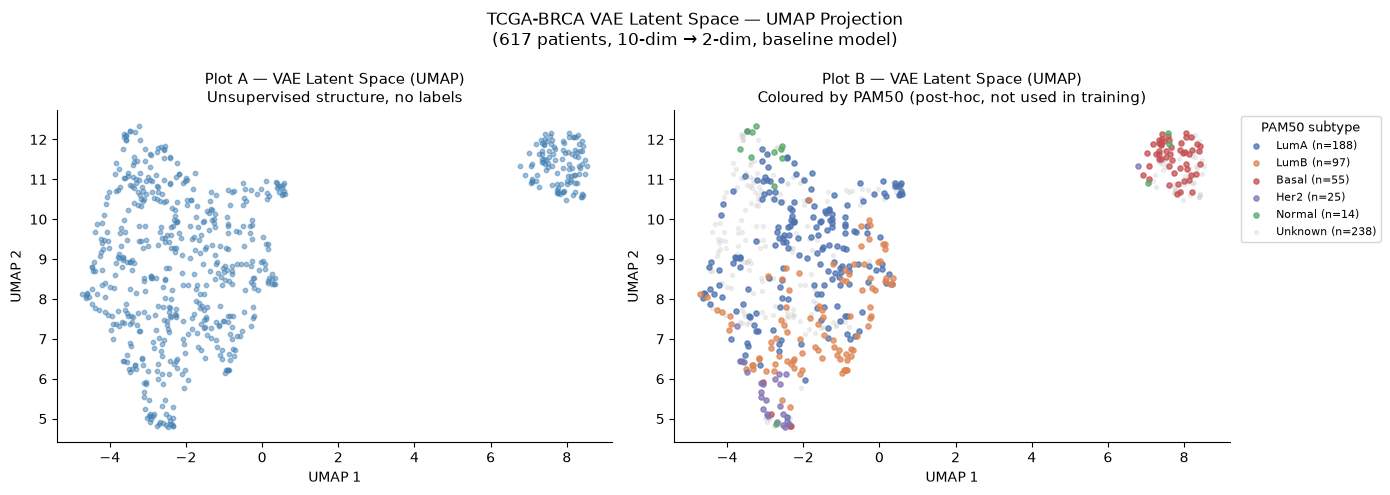

In [13]:
# ── PAM50 colour palette ───────────────────────────────────────────────────────
SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {
    "LumA"   : "#4C72B0",
    "LumB"   : "#DD8452",
    "Basal"  : "#C44E52",
    "Her2"   : "#8172B3",
    "Normal" : "#55A868",
    "Unknown": "#CCCCCC",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot A: No annotation (unsupervised structure) ─────────────────────────────
axes[0].scatter(Z_2d[:, 0], Z_2d[:, 1], s=10, color="steelblue",
                alpha=0.5, rasterized=True)
axes[0].set_title("Plot A — VAE Latent Space (UMAP)\n"
                  "Unsupervised structure, no labels",
                  fontsize=11)
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Plot B: Coloured by PAM50 (post-hoc only) ─────────────────────────────────
for st in SUBTYPE_ORDER:
    mask = pam50_labels.values == st
    if mask.sum() == 0:
        continue
    alpha = 0.3 if st == "Unknown" else 0.75
    size  = 8   if st == "Unknown" else 14
    axes[1].scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                    s=size, color=SUBTYPE_COLORS[st], alpha=alpha,
                    label=f"{st} (n={mask.sum()})", rasterized=True, zorder=2 if st != "Unknown" else 1)

axes[1].set_title("Plot B — VAE Latent Space (UMAP)\n"
                  "Coloured by PAM50 (post-hoc, not used in training)",
                  fontsize=11)
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=8, title_fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("TCGA-BRCA VAE Latent Space — UMAP Projection\n"
             "(617 patients, 10-dim → 2-dim, baseline model)",
             fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_UMAP_PAM50.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 11. K-means clustering

**Next,** run K-means with five clusters on the full 10-dimensional VAE representation and show those clusters on the UMAP display. K-means receives latent coordinates only, never PAM50 labels. **Look for** the cluster sizes and how clusters occupy the UMAP view.


K-means cluster sizes (k=5, on 10-D latent space):
  Cluster 0: 164 samples
  Cluster 1: 112 samples
  Cluster 2: 113 samples
  Cluster 3: 92 samples
  Cluster 4: 136 samples


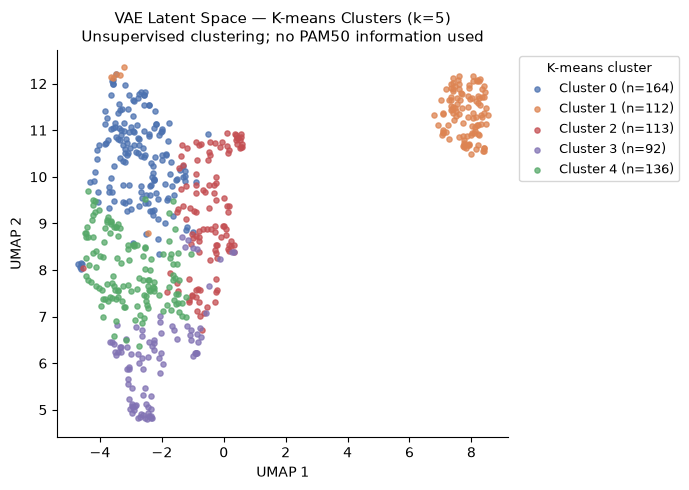

In [14]:
# ── K-means clustering on 10-D latent space (no labels) ──────────────────────
K = 5   # chosen to match number of PAM50 subtypes; NOT fitted to labels

km = KMeans(n_clusters=K, random_state=VAE_SEED, n_init=20)
cluster_labels = km.fit_predict(latent_df.values)   # operates on 10-D latent, no PAM50

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("K-means cluster sizes (k=5, on 10-D latent space):")
for c, n in cluster_sizes.items():
    print(f"  Cluster {c}: {n} samples")

# ── UMAP coloured by cluster ───────────────────────────────────────────────────
cluster_palette = {i: c for i, c in enumerate(
    ["#4C72B0", "#DD8452", "#C44E52", "#8172B3", "#55A868"])}

fig, ax = plt.subplots(figsize=(7, 5))
for c in range(K):
    mask = cluster_labels == c
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               s=14, color=cluster_palette[c], alpha=0.75,
               label=f"Cluster {c} (n={mask.sum()})", rasterized=True)

ax.set_title("VAE Latent Space — K-means Clusters (k=5)\n"
             "Unsupervised clustering; no PAM50 information used",
             fontsize=11)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(title="K-means cluster", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_UMAP_clusters.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 12. Comparing learned clusters with PAM50

PAM50 is a known breast-cancer expression-based subtype annotation in the cohort metadata. It is introduced now, after VAE training and clustering, solely as an external reference.

**Next,** compare cluster assignments with available PAM50 labels using a contingency table, ARI, NMI, and heatmaps. Patients with unknown PAM50 labels remain in VAE training and K-means, but are excluded only where a reference label is required. **Look for** the labelled-sample count, the table, and the reported agreement scores.

## 13. Interpreting ARI and NMI

ARI and NMI summarise agreement between two partitions: 1 indicates perfect agreement and values near 0 indicate little agreement beyond chance (ARI) or little shared information (NMI). They do not prove that the VAE has rediscovered PAM50, because the model integrates three modalities and was not optimised to reproduce this external annotation.


Samples with PAM50 labels : 379 / 617

Contingency table (counts):
PAM50 subtype    LumA  LumB  Basal  Her2  Normal
K-means cluster                                 
0                  73     5      0     1       7
1                   0     1     51     1       6
2                  56    31      0     0       0
3                  12    41      4    22       1
4                  47    19      0     1       0

Adjusted Rand Index (ARI) : 0.2396
Normalised Mutual Info (NMI): 0.3860

Interpretation:
  ARI = 1.0 → perfect agreement; ARI = 0 → random agreement
  NMI = 1.0 → perfect mutual information; NMI = 0 → none

⚠️  ARI and NMI measure agreement between unsupervised clusters and PAM50.
   They do NOT prove that the VAE rediscovered PAM50 subtypes.
   The VAE integrates 3 modalities and is not optimised to reproduce PAM50.


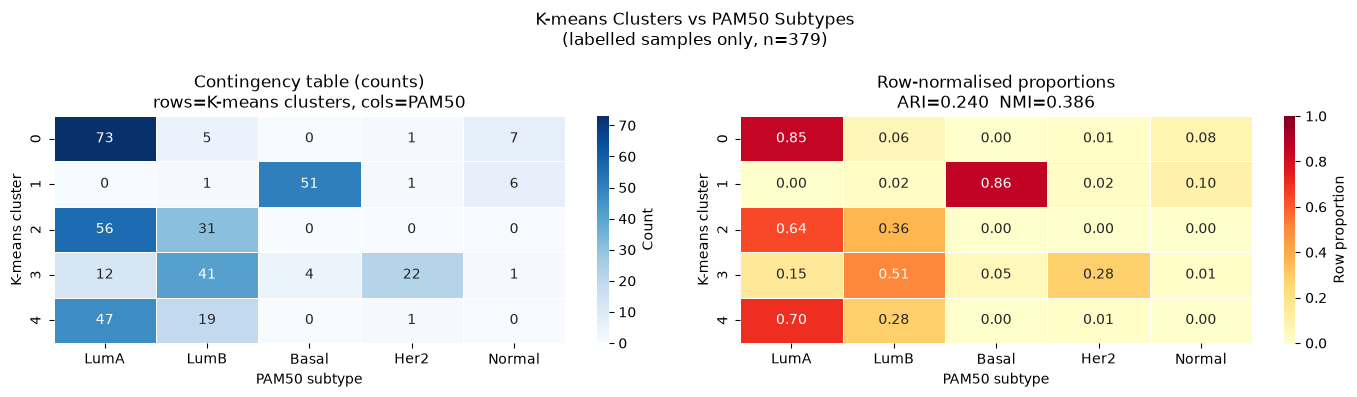

In [15]:
# ── Restrict to samples with known PAM50 labels for contingency analysis ───────
has_pam50_mask = pam50_labels.values != "Unknown"
clusters_labelled = cluster_labels[has_pam50_mask]
pam50_labelled    = pam50_labels.values[has_pam50_mask]

n_labelled = has_pam50_mask.sum()
print(f"Samples with PAM50 labels : {n_labelled} / 617")

# ── Contingency table ─────────────────────────────────────────────────────────
contingency = pd.crosstab(
    pd.Series(clusters_labelled, name="K-means cluster"),
    pd.Series(pam50_labelled,    name="PAM50 subtype"),
)
# Ensure consistent column ordering
for st in SUBTYPE_ORDER[:-1]:   # exclude "Unknown"
    if st not in contingency.columns:
        contingency[st] = 0
contingency = contingency[[s for s in SUBTYPE_ORDER if s in contingency.columns]]

print("\nContingency table (counts):")
print(contingency.to_string())

# ── ARI and NMI ───────────────────────────────────────────────────────────────
ari = adjusted_rand_score(pam50_labelled, clusters_labelled)
nmi = normalized_mutual_info_score(pam50_labelled, clusters_labelled, average_method="arithmetic")

print(f"\nAdjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalised Mutual Info (NMI): {nmi:.4f}")
print()
print("Interpretation:")
print("  ARI = 1.0 → perfect agreement; ARI = 0 → random agreement")
print("  NMI = 1.0 → perfect mutual information; NMI = 0 → none")
print()
print("⚠️  ARI and NMI measure agreement between unsupervised clusters and PAM50.")
print("   They do NOT prove that the VAE rediscovered PAM50 subtypes.")
print("   The VAE integrates 3 modalities and is not optimised to reproduce PAM50.")

# ── Normalised contingency heatmap ────────────────────────────────────────────
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)   # row proportions

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Count"})
axes[0].set_title("Contingency table (counts)\nrows=K-means clusters, cols=PAM50")

sns.heatmap(contingency_norm.round(2), annot=True, fmt=".2f",
            cmap="YlOrRd", ax=axes[1], linewidths=0.5,
            vmin=0, vmax=1, cbar_kws={"label": "Row proportion"})
axes[1].set_title(f"Row-normalised proportions\nARI={ari:.3f}  NMI={nmi:.3f}")

plt.suptitle("K-means Clusters vs PAM50 Subtypes\n"
             "(labelled samples only, n={})".format(n_labelled), fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_contingency.png",
            dpi=150, bbox_inches="tight")
plt.show()

### PAM50 composition within clusters

**Next,** plot the PAM50 composition of each learned cluster among patients with known labels. This is another post-hoc description, not a supervised evaluation target. **Look for** mixed or enriched subtype compositions without interpreting them as a biological claim beyond what the displayed data support.


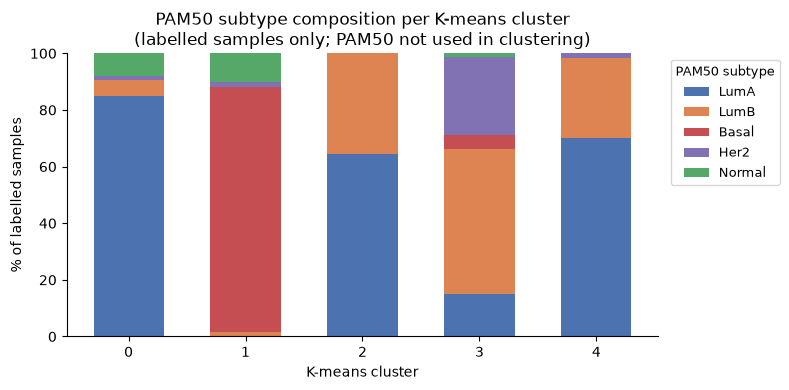

Cluster compositions (% PAM50 in labelled samples per cluster):
PAM50    LumA  LumB  Basal  Her2  Normal
cluster                                 
0        84.9   5.8    0.0   1.2     8.1
1         0.0   1.7   86.4   1.7    10.2
2        64.4  35.6    0.0   0.0     0.0
3        15.0  51.2    5.0  27.5     1.2
4        70.1  28.4    0.0   1.5     0.0


In [16]:
# ── Stacked bar chart: PAM50 composition within each cluster ──────────────────
cluster_pam50 = pd.DataFrame({
    "cluster": cluster_labels[has_pam50_mask],
    "PAM50"  : pam50_labelled,
})
stacked = cluster_pam50.groupby(["cluster", "PAM50"]).size().unstack(fill_value=0)
# Ensure column order
stacked = stacked.reindex(columns=[s for s in SUBTYPE_ORDER if s in stacked.columns], fill_value=0)
stacked_pct = stacked.div(stacked.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(stacked_pct))
for st in stacked_pct.columns:
    ax.bar(stacked_pct.index, stacked_pct[st], bottom=bottom,
           color=SUBTYPE_COLORS.get(st, "#999"), label=st, width=0.6)
    bottom += stacked_pct[st].values

ax.set_xlabel("K-means cluster"); ax.set_ylabel("% of labelled samples")
ax.set_title("PAM50 subtype composition per K-means cluster\n"
             "(labelled samples only; PAM50 not used in clustering)")
ax.legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, title_fontsize=9)
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_cluster_composition.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Cluster compositions (% PAM50 in labelled samples per cluster):")
print(stacked_pct.round(1).to_string())

## 14. Autoencoder vs Variational Autoencoder

A plain **Autoencoder (AE)** learns a deterministic 10-dimensional bottleneck using reconstruction loss alone. The **VAE** has a related encoder/decoder structure but learns a distribution in latent space and adds KL regularisation. Both methods are unsupervised: PAM50 is not used to train either model.

**Next,** rebuild the same frozen inputs, split, and training-only scaling used for the VAE so that the AE comparison is fair. **Look for** the same 617-patient cohort, 2,300 inputs, and train/validation split.


In [17]:
import random, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Paths & seeds (identical protocol to Part 15) ─────────────────────────────
FIG_DIR = PROCESSED_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

random.seed(VAE_SEED); np.random.seed(VAE_SEED); torch.manual_seed(VAE_SEED)

# ── Load frozen processed matrices (unchanged inputs) ─────────────────────────
rna_df   = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",   sep="\t", index_col=0)
mirna_df = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv", sep="\t", index_col=0)
meth_df  = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv", sep="\t", index_col=0)
cohort_meta = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv", sep="\t", index_col="sample_id")
frozen_ids = cohort_meta.index.tolist()

assert list(rna_df.index) == list(mirna_df.index) == list(meth_df.index) == frozen_ids

# ── Same split & scaling as the VAE section (identical seed → identical split) ─
VAL_FRAC, BATCH_SIZE = 0.20, 64
sample_array = np.array(frozen_ids)
idx_all = np.arange(len(sample_array))
idx_train, idx_val = train_test_split(idx_all, test_size=VAL_FRAC,
                                      random_state=VAE_SEED, shuffle=True)
train_ids = sample_array[idx_train].tolist()

def fit_scale(df, tr_ids):
    sc = StandardScaler().fit(df.loc[tr_ids].values)
    return sc.transform(df.values).astype(np.float32)

X_all = np.concatenate([fit_scale(rna_df, train_ids),
                        fit_scale(mirna_df, train_ids),
                        fit_scale(meth_df, train_ids)], axis=1)
INPUT_DIM = X_all.shape[1]
LATENT_DIM = 10

X_tensor = torch.tensor(X_all, dtype=torch.float32)
X_train_t, X_val_t = X_tensor[idx_train], X_tensor[idx_val]
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH_SIZE, shuffle=False)

print(f"Figures dir : {FIG_DIR}")
print(f"Cohort      : {len(frozen_ids)} samples | input dim {INPUT_DIM} | latent {LATENT_DIM}")
print(f"Train/val   : {len(idx_train)}/{len(idx_val)} (same split & scaling as VAE)")

Figures dir : c:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\figures
Cohort      : 617 samples | input dim 2300 | latent 10
Train/val   : 493/124 (same split & scaling as VAE)


### Train the plain autoencoder

**Next,** train the AE with the same latent dimension and a reconstruction-only objective. This lets us compare the effect of VAE regularisation without changing the cohort or preprocessing protocol. **Look for** the AE architecture, its reconstruction losses, and the best epoch.


In [18]:
class AE(nn.Module):
    """Same encoder/decoder topology as the VAE, but deterministic bottleneck
    (no mu/logvar heads, no KL term)."""
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

torch.manual_seed(VAE_SEED)
ae = AE(INPUT_DIM, LATENT_DIM)
ae_n_params = sum(p.numel() for p in ae.parameters() if p.requires_grad)
print("AE architecture:")
print(ae)
print(f"\nTrainable parameters: {ae_n_params:,}")

LR, MAX_EPOCHS, PATIENCE = 1e-3, 100, 15
AE_CKPT = PROCESSED_DIR / "TCGA_BRCA_AE_best.pt"
opt = torch.optim.Adam(ae.parameters(), lr=LR)
ae_history = {"train_recon": [], "val_recon": []}
best_val, best_epoch, patience_ct = float("inf"), 0, 0
t0 = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    ae.train()
    tr = 0.0
    for (xb,) in train_loader:
        opt.zero_grad()
        loss = F.mse_loss(ae(xb), xb, reduction="mean")
        loss.backward(); opt.step()
        tr += loss.item()
    ae_history["train_recon"].append(tr / len(train_loader))

    ae.eval()
    va = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            va += F.mse_loss(ae(xb), xb, reduction="mean").item()
    va /= len(val_loader)
    ae_history["val_recon"].append(va)

    if va < best_val:
        best_val, best_epoch, patience_ct = va, epoch, 0
        torch.save({"epoch": epoch, "model_state": ae.state_dict(), "val_recon": va}, AE_CKPT)
    else:
        patience_ct += 1
        if patience_ct >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train recon={ae_history['train_recon'][-1]:.5f} "
              f"| val recon={va:.5f}")

elapsed = time.time() - t0
ckpt = torch.load(AE_CKPT, weights_only=True)
ae.load_state_dict(ckpt["model_state"]); ae.eval()
ae_best_epoch = ckpt["epoch"]
print(f"\nTraining finished: {len(ae_history['train_recon'])} epochs in {elapsed:.1f}s")
print(f"Best epoch: {ae_best_epoch} | best val recon (MSE): {best_val:.5f}")

AE architecture:
AE(
  (encoder): Sequential(
    (0): Linear(in_features=2300, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=2300, bias=True)
  )
)

Trainable parameters: 1,215,878
Epoch   1 | train recon=1.01987 | val recon=0.87790


### Reconstruction-loss comparison

**Next,** evaluate the saved VAE and AE on the same validation patients. Reconstruction loss measures how closely a model rebuilds scaled input features; it does not by itself determine which latent space is more useful for every downstream task. **Look for** both validation MSE values and the printed difference.


Reconstruction loss on validation set (MSE, mean over elements)
  VAE : 0.59280   (best epoch 69)
  AE  : 0.58143   (best epoch 36)
  Δ (AE − VAE): -0.01137 (-1.92%)

Interpretation: reconstruction quality is essentially comparable.
The VAE's advantage lies in its smooth, probabilistic latent space
(regularised by the KL term toward N(0,I)), not in lower MSE.


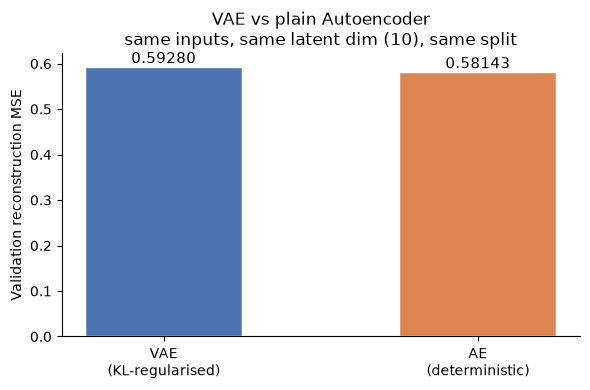

✅ Saved: data/processed/figures/VAE_vs_AE_reconstruction.png
✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_comparison.json


In [19]:
# ── Rebuild the trained VAE exactly as in Part 15 and evaluate both on val set ─
class _Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU())
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
    def forward(self, x):
        h = self.net(x); return self.fc_mu(h), self.fc_logvar(h)

class _Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, output_dim))
    def forward(self, z): return self.net(z)

class _VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = _Encoder(input_dim, latent_dim)
        self.decoder = _Decoder(latent_dim, input_dim)
    def forward(self, x):
        mu, logvar = self.encoder(x)
        return self.decoder(mu), mu, logvar

ckpt_vae = torch.load(PROCESSED_DIR / "TCGA_BRCA_VAE_best.pt", weights_only=True)
vae_cmp = _VAE(INPUT_DIM, LATENT_DIM)
vae_cmp.load_state_dict(ckpt_vae["model_state"]); vae_cmp.eval()

with torch.no_grad():
    vr = ar = 0.0
    for (xb,) in val_loader:
        x_hat, _, _ = vae_cmp(xb)
        vr += F.mse_loss(x_hat, xb, reduction="mean").item()
        ar += F.mse_loss(ae(xb), xb, reduction="mean").item()
    vae_val_recon = vr / len(val_loader)
    ae_val_recon  = ar / len(val_loader)

comparison = {
    "vae_val_recon_mse": round(vae_val_recon, 6),
    "ae_val_recon_mse":  round(ae_val_recon, 6),
    "delta_ae_minus_vae": round(ae_val_recon - vae_val_recon, 6),
    "pct_difference": round(100 * (ae_val_recon - vae_val_recon) / vae_val_recon, 2),
    "vae_best_epoch": ckpt_vae["epoch"],
    "ae_best_epoch": ae_best_epoch,
    "ae_params": ae_n_params,
}
print("Reconstruction loss on validation set (MSE, mean over elements)")
print("=" * 55)
print(f"  VAE : {vae_val_recon:.5f}   (best epoch {ckpt_vae['epoch']})")
print(f"  AE  : {ae_val_recon:.5f}   (best epoch {ae_best_epoch})")
d = ae_val_recon - vae_val_recon
print(f"  Δ (AE − VAE): {d:+.5f} ({comparison['pct_difference']:+.2f}%)")
print()
if abs(d) < 0.02 * vae_val_recon:
    print("Interpretation: reconstruction quality is essentially comparable.")
    print("The VAE's advantage lies in its smooth, probabilistic latent space")
    print("(regularised by the KL term toward N(0,I)), not in lower MSE.")
elif d > 0:
    print("Interpretation: the AE reconstructs slightly better — expected, since")
    print("it spends ALL of its capacity on reconstruction with no KL constraint.")
else:
    print("Interpretation: the VAE reconstructs slightly better despite the KL")
    print("constraint acting as a regulariser against overfitting.")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["VAE\n(KL-regularised)", "AE\n(deterministic)"],
              [vae_val_recon, ae_val_recon],
              color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for b, v in zip(bars, [vae_val_recon, ae_val_recon]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0002, f"{v:.5f}",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Validation reconstruction MSE")
ax.set_title("VAE vs plain Autoencoder\nsame inputs, same latent dim (10), same split")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "VAE_vs_AE_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: data/processed/figures/VAE_vs_AE_reconstruction.png")

with open(PROCESSED_DIR / "TCGA_BRCA_VAE_vs_AE_comparison.json", "w") as fh:
    json.dump(comparison, fh, indent=2)
print("✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_comparison.json")

### Latent-space comparison via UMAP

**Next,** compare UMAP displays of the VAE and AE latent spaces, then perform the same post-hoc K-means-versus-PAM50 check. The models, UMAP fitting, and clustering use no PAM50 labels; PAM50 appears only afterward for visualisation and agreement summaries. **Look for** how the two unsupervised representations differ, while avoiding conclusions beyond the shown metrics.


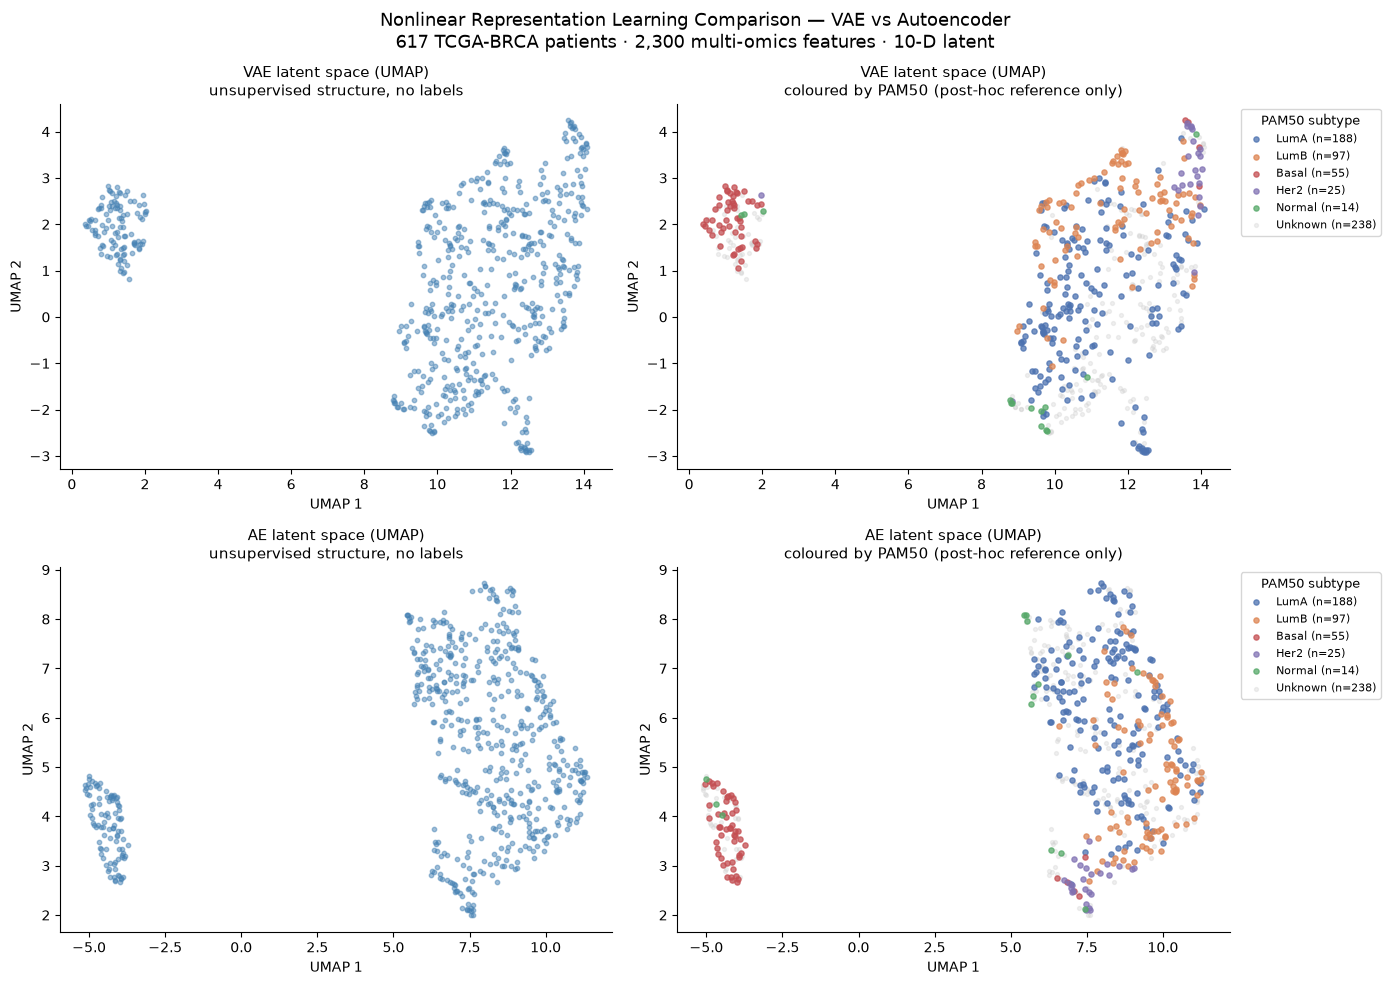

✅ Saved: data/processed/figures/VAE_vs_AE_UMAP_PAM50.png

Post-hoc PAM50 agreement (k-means k=5 on 10-D latent; labels NOT used in fitting):
       ARI_vs_PAM50  NMI_vs_PAM50
model                            
VAE          0.2396        0.3860
AE           0.2741        0.4377

⚠️  PAM50 used strictly post-hoc as an external biological reference.
✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_PAM50_posthoc.tsv


In [20]:
import umap as umap_lib
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

# ── Extract latents (no labels used anywhere in the embedding) ────────────────
with torch.no_grad():
    z_vae = vae_cmp.encoder(X_tensor)[0].numpy()          # mu, (617, 10)
    z_ae  = ae.encoder(X_tensor).numpy()                  # (617, 10)

pam50_labels = cohort_meta["PAM50_subtype"].reindex(frozen_ids).fillna("Unknown")

reducer_vae = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
reducer_ae  = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_vae = reducer_vae.fit_transform(z_vae)
emb_ae  = reducer_ae.fit_transform(z_ae)

SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {"LumA": "#4C72B0", "LumB": "#DD8452", "Basal": "#C44E52",
                  "Her2": "#8172B3", "Normal": "#55A868", "Unknown": "#CCCCCC"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, (emb, name) in enumerate([(emb_vae, "VAE"), (emb_ae, "AE")]):
    axes[row, 0].scatter(emb[:, 0], emb[:, 1], s=10, color="steelblue",
                         alpha=0.5, rasterized=True)
    axes[row, 0].set_title(f"{name} latent space (UMAP)\nunsupervised structure, no labels",
                           fontsize=11)
    axes[row, 0].set_xlabel("UMAP 1"); axes[row, 0].set_ylabel("UMAP 2")
    axes[row, 0].spines[["top", "right"]].set_visible(False)

    for st in SUBTYPE_ORDER:
        mask = pam50_labels.values == st
        if mask.sum() == 0:
            continue
        alpha = 0.3 if st == "Unknown" else 0.75
        size  = 8   if st == "Unknown" else 14
        axes[row, 1].scatter(emb[mask, 0], emb[mask, 1], s=size,
                             color=SUBTYPE_COLORS[st], alpha=alpha,
                             label=f"{st} (n={mask.sum()})", rasterized=True,
                             zorder=2 if st != "Unknown" else 1)
    axes[row, 1].set_title(f"{name} latent space (UMAP)\ncoloured by PAM50 (post-hoc reference only)",
                           fontsize=11)
    axes[row, 1].set_xlabel("UMAP 1"); axes[row, 1].set_ylabel("UMAP 2")
    axes[row, 1].legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1),
                        loc="upper left", fontsize=8, title_fontsize=9)
    axes[row, 1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Nonlinear Representation Learning Comparison — VAE vs Autoencoder\n"
             "617 TCGA-BRCA patients · 2,300 multi-omics features · 10-D latent",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "VAE_vs_AE_UMAP_PAM50.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: data/processed/figures/VAE_vs_AE_UMAP_PAM50.png")

# ── Post-hoc quantitative check: k-means (k=5) vs PAM50, labelled samples only ─
rows = []
has_lbl = pam50_labels.values != "Unknown"
for z, name in [(z_vae, "VAE"), (z_ae, "AE")]:
    km = KMeans(n_clusters=5, random_state=42, n_init=20).fit_predict(z)
    ari = adjusted_rand_score(pam50_labels.values[has_lbl], km[has_lbl])
    nmi = normalized_mutual_info_score(pam50_labels.values[has_lbl], km[has_lbl])
    rows.append({"model": name, "ARI_vs_PAM50": round(ari, 4),
                 "NMI_vs_PAM50": round(nmi, 4)})
posthoc = pd.DataFrame(rows).set_index("model")
print("\nPost-hoc PAM50 agreement (k-means k=5 on 10-D latent; labels NOT used in fitting):")
print(posthoc.to_string())
print("\n⚠️  PAM50 used strictly post-hoc as an external biological reference.")

posthoc.to_csv(PROCESSED_DIR / "TCGA_BRCA_VAE_vs_AE_PAM50_posthoc.tsv", sep="\t")
print("✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_PAM50_posthoc.tsv")

## 15. Final take-home message

Multi-omics integration can be framed as representation learning: the VAE compresses RNA-seq, miRNA, and DNA methylation measurements into a shared 10-dimensional patient representation. We used a training-only preprocessing workflow, visualised and clustered the learned space without labels, and only then compared it with PAM50 as an external biological reference.

The AE comparison illustrates the trade-off: a plain AE optimises reconstruction alone, whereas a VAE also regularises its latent space. The outputs in this notebook should be interpreted as a guided demonstration of this workflow, not as new biological conclusions.
